In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold,cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.pipeline import Pipeline as pipeline
from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier
import joblib

In [16]:
data=pd.read_csv('data/star_classification.csv')

In [17]:
print(data.isnull().sum())

obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64


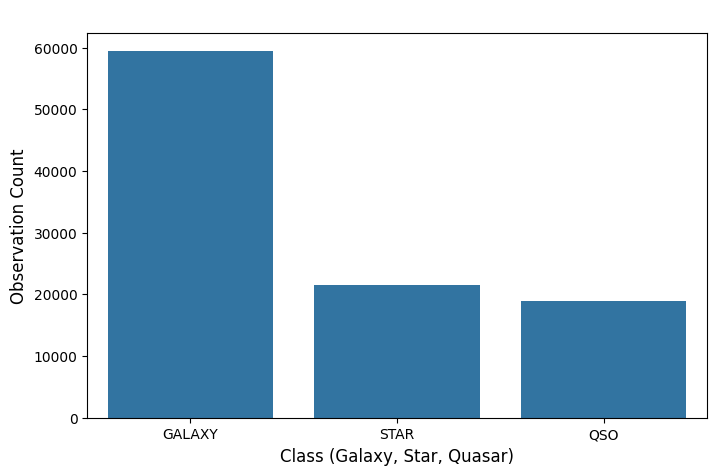

In [18]:
plt.figure(figsize=(8,5))
ax = sns.countplot(data=data, x='class', order=data['class'].value_counts().index)

plt.title('Distribution of Stellar Classes', fontsize=14, fontweight='bold', color='white')
plt.xlabel('Class (Galaxy, Star, Quasar)', fontsize=12)
plt.ylabel('Observation Count', fontsize=12)

plt.show()

## The data is slightly imbalanced with most values for galaxy shout fix it with smoot or better underfitting

In [19]:
data.columns

Index(['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID',
       'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift',
       'plate', 'MJD', 'fiber_ID'],
      dtype='object')

In [20]:
columns_to_drop = ['obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID']
df_features = data.drop(columns=columns_to_drop)

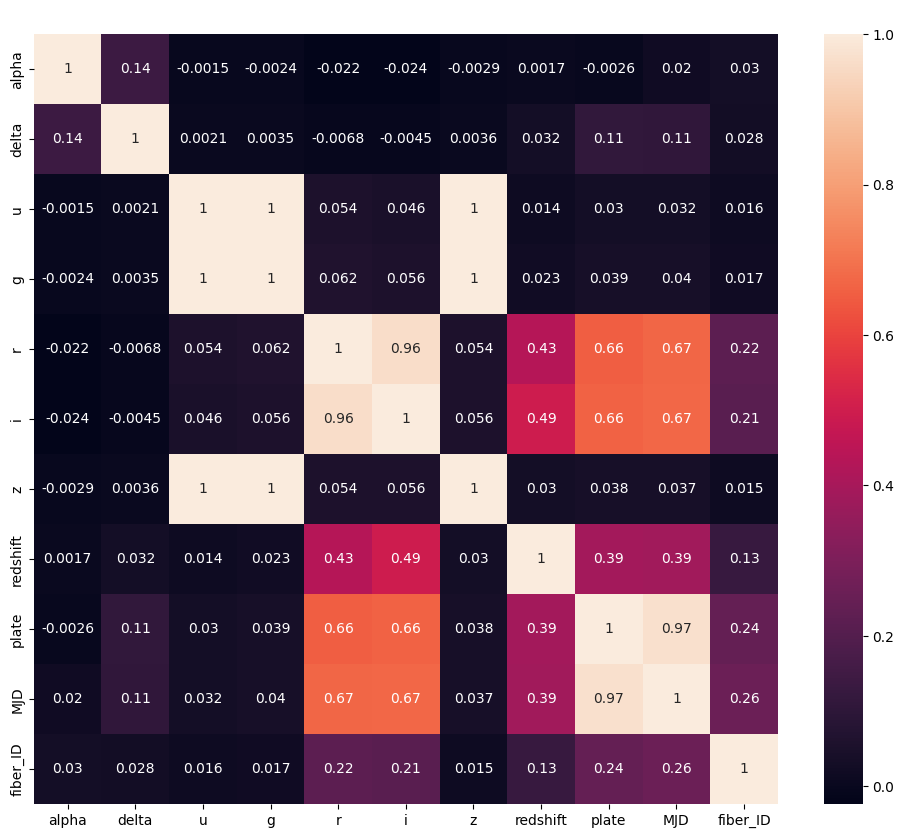

In [21]:
correlation_matrix = df_features.drop(columns=['class']).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix,annot=True)

plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', color='white')
plt.show()

## High correlation between plate and MJD also plate,MJD,r and i, also with redshift , MJD , Plate ,r and i

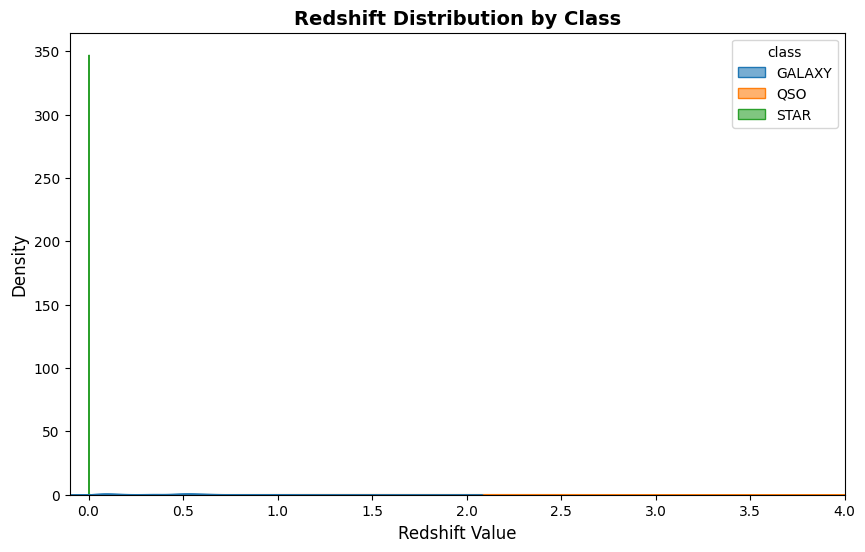

In [22]:
plt.figure(figsize=(10, 6))

# Plot the distribution of redshift for each class
sns.kdeplot(data=data, x='redshift', hue='class', fill=True, alpha=0.6)

plt.title('Redshift Distribution by Class', fontsize=14, fontweight='bold')
plt.xlabel('Redshift Value', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(-0.1, 4) # Limiting X-axis to filter out extreme outliers for better visualization

plt.show()

In [23]:
x=data.drop(columns=columns_to_drop+["class"])
y=data["class"]

In [24]:
f_score,p_value=f_classif(x,y)
p_value_df=pd.DataFrame({
    'Feature': x.columns,
    'F-Score': f_score,
    'P-Value': p_value
})
p_value_df['P-Value'] = p_value_df['P-Value'].apply(lambda x: f"{x:.6f}" if x > 0.000001 else "0.000000 (Highly Significant)")
p_value_df = p_value_df.sort_values(by='F-Score', ascending=False).reset_index(drop=True)

print("--- Feature Significance Report ---")
display(p_value_df)

--- Feature Significance Report ---


,Feature,F-Score,P-Value
0,redshift,83429.418967,0.000000 (Highly Significant)
1,i,8282.343545,0.000000 (Highly Significant)
2,plate,5169.585517,0.000000 (Highly Significant)
3,r,4584.533364,0.000000 (Highly Significant)
4,MJD,4427.629371,0.000000 (Highly Significant)
5,fiber_ID,436.795027,0.000000 (Highly Significant)
6,delta,217.588357,0.000000 (Highly Significant)
7,z,32.328308,0.000000 (Highly Significant)
8,u,30.445339,0.000000 (Highly Significant)
9,g,25.962523,0.000000 (Highly Significant)


In [25]:
x=data.drop(columns=["plate","alpha","MJD","fiber_ID","g","class"])

In [26]:
le=LabelEncoder()
y_encoded=le.fit_transform(y)

print("X features:", x.dtypes)
print("y data type:", y_encoded)

X features: obj_ID         float64
delta          float64
u              float64
r              float64
i              float64
z              float64
run_ID           int64
rerun_ID         int64
cam_col          int64
field_ID         int64
spec_obj_ID    float64
redshift       float64
dtype: object
y data type: [0 0 0 ... 0 0 0]


In [27]:
Pipe=pipeline(steps=[
('smote', SMOTE(random_state=42)),
('classifier', RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)) 
])

cv_stratergy=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [28]:
scores=cross_val_score(Pipe,x,y_encoded,cv=cv_stratergy,scoring='balanced_accuracy',n_jobs=-1)

# 5. Output the Results
print("\n--- Cross-Validation Results ---")
print(f"F1-Scores for each fold: {np.round(scores, 4)}")
print(f"Mean F1-ba: {scores.mean():.4f}")
print(f"Standard Deviation: {scores.std():.4f}")

if scores.std() < 0.02:
    print("[+] Status: Highly Stable. The model performs consistently across all splits.")
else:
    print("[-] Status: Unstable. The model's performance fluctuates depending on the split.")


--- Cross-Validation Results ---
F1-Scores for each fold: [0.9728 0.9714 0.9758 0.9718 0.9733]
Mean F1-ba: 0.9730
Standard Deviation: 0.0015
[+] Status: Highly Stable. The model performs consistently across all splits.


In [29]:
joblib.dump(Pipe,"models/stellar_rf_pipeline.joblib")
print("[+] Random Forest Pipeline saved successfully.")

[+] Random Forest Pipeline saved successfully.


In [30]:
joblib.dump(le,"models/label_encoder.joblib")

['models/label_encoder.joblib']